In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.io import loadmat

CHUNK1

In [115]:
data = loadmat(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\DDC_Tools\Split_mau_corrected.mat")  # replace with actual .mat filename
Pre_A = 100
Resolution = 70

# MATLAB structs often wrap variables in extra arrays, so we need to unwrap
LocalizationsFinal = [arr for arr in data['LocalizationsFinal'].flatten()]
Frame_Information = [arr.flatten() for arr in data['Frame_Information'].flatten()]

D_maxf = 0
D_maxm = np.inf

# Find global min/max distances
for locs in LocalizationsFinal:
    D = pdist(locs)
    D_max = D.max()
    if D_max > D_maxf:
        D_maxf = D_max
    if D_max < D_maxm:
        D_maxm = D_max

bins = np.concatenate([np.arange(0, D_maxf, Resolution), [np.inf]])

Total_Blink = []
Total_No_Blink = []

for locs, frames in zip(LocalizationsFinal, Frame_Information):
    Z2 = pdist(np.column_stack([np.zeros(len(frames)), frames]))
    D = pdist(locs)

    D_Blink = D[Z2 < Pre_A]
    mask_no_blink = (Z2 > Pre_A) & (Z2 < Pre_A * 5)
    D_No_Blink = D[mask_no_blink]

    # Blink
    counts, _ = np.histogram(D_Blink, bins=bins, density=False)
    D_Counts = counts / counts.sum() if counts.sum() > 0 else counts
    Total_Blink.append(D_Counts)

    # No Blink
    counts2, _ = np.histogram(D_No_Blink, bins=bins, density=False)
    D_Counts2 = counts2 / counts2.sum() if counts2.sum() > 0 else counts2
    Total_No_Blink.append(D_Counts2)

blink_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\Total_Blink.csv", header=None).values
no_blink_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\Total_No_Blink.csv", header=None).values
print("Bins identical:", np.allclose(bins_mat, bins, atol=1e-8))
print("Total_Blink identical:", np.allclose(blink_mat, np.array(Total_Blink), atol=1e-8))
print("Total_No_Blink identical:", np.allclose(no_blink_mat, np.array(Total_No_Blink), atol=1e-8))

Bins identical: True
Total_Blink identical: True
Total_No_Blink identical: True


CHUNK2

In [70]:
# Step 2: Scale probability distributions
D_Counts = blink_py.mean(axis=0)       # mean across images
D_Counts2 = no_blink_py.mean(axis=0)

# Scale factor
D_Scale = D_Counts[9:].sum() / D_Counts2[9:].sum()   # index 10:end in MATLAB = 9: in Python

D_Counts3 = D_Counts - D_Counts2 * D_Scale
D_Counts3 = D_Counts3 / D_Counts3.sum()

# Clean up distribution
good = 1
ins = 0
for i in range(3, len(D_Counts3)-1):   # MATLAB 4:end → Python index 3:
    if D_Counts3[i] > 0 and D_Counts3[i+1] < D_Counts3[i] and good == 1:
        pass  # keep it
    else:
        if ins == 0:
            ins = i
        good = 0
        D_Counts3[i] = 0

D_Counts3[D_Counts3 < 0] = 0
D_Counts3 = D_Counts3 / D_Counts3.sum()
D_Counts3 = D_Counts3 / D_Counts3.sum()

# Eliminate noise after 8×Resolution
if np.sum(D_Counts3[7:] > 0) > 1:     # MATLAB 8:end → Python index 7:
    print("Warning: Eliminating Noise for higher bins")
    D_Counts3[7:] = 0
    D_Counts3 = D_Counts3 / D_Counts3.sum()

# Load MATLAB results
D_Counts_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\D_Counts.csv", header=None).values.flatten()
D_Counts2_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\D_Counts2.csv", header=None).values.flatten()
D_Counts3_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\D_Counts3.csv", header=None).values.flatten()

print("D_Counts identical:", np.allclose(D_Counts_mat, D_Counts, atol=1e-8))
print("D_Counts2 identical:", np.allclose(D_Counts2_mat, D_Counts2, atol=1e-8))
print("D_Counts3 identical:", np.allclose(D_Counts3_mat, D_Counts3, atol=1e-8))


D_Counts identical: True
D_Counts2 identical: True
D_Counts3 identical: True


CHUNK3

Error from fitting in this part. Eror is in D_scale

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.optimize import least_squares, curve_fit

# === Helper using SciPy TRF solver ===
def fit_scale_trf(T, B, y):
    """Fit y ≈ x*T + (1-x)*B with TRF (SciPy version)."""
    def residual(x):
        return (x[0]*T + (1-x[0])*B) - y
    
    res = least_squares(
        residual,
        x0=[1.0],
        bounds=(0.0, 1.0),
        method="trf",       # Trust Region Reflective
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12
    )
    return res.x[0]

def fit_scale_curvefit(T, B, y):
    """Fit y ≈ x*T + (1-x)*B using curve_fit (closer to MATLAB lsqcurvefit)."""
    def model(x, t0, t1):
        return x * t0 + (1 - x) * t1

    # curve_fit expects function f(xdata, params), so we pass t0, t1 as "xdata"
    t0, t1 = T, B
    xdata = np.vstack([t0, t1])  # stack like MATLAB's [True; Blink]

    def F(xdata, x):
        return x * xdata[0,:] + (1-x) * xdata[1,:]

    # Initial guess = 1, bounds = [0,1]
    popt, _ = curve_fit(F, xdata, y, p0=[1.0], bounds=(0,1))
    return popt[0]

# === Step 3: Fitting distributions and M matrix ===
Distribution_for_Blink2 = D_Counts3.copy()
Dscale_store = []

print("Still Working on step 1, wait for me")

for i, (locs, frames) in enumerate(zip(LocalizationsFinal, Frame_Information)):
    Z2 = pdist(np.column_stack([np.zeros(len(frames)), frames]))
    D = pdist(locs)

    # True distribution (no blink)
    D_No_Blink = D[(Z2 > Pre_A) & (Z2 < Pre_A*5)]
    True_Distribuiton2, _ = np.histogram(D_No_Blink, bins=bins, density=False)
    True_Distribuiton2 = True_Distribuiton2 / True_Distribuiton2.sum() if True_Distribuiton2.sum() > 0 else True_Distribuiton2

    scales = []
    for w in range(1, Pre_A+1):
        # Blink distribution at frame diff w
        D_Blink = D[Z2 == w]
        Temp_Distribution, _ = np.histogram(D_Blink, bins=bins, density=False)
        Temp_Distribution = Temp_Distribution / Temp_Distribution.sum() if Temp_Distribution.sum() > 0 else Temp_Distribution
        y = Temp_Distribution

        # --- TRF solver (SciPy) ---
        D_Scale = fit_scale_trf(True_Distribuiton2, Distribution_for_Blink2, y)
        scales.append(D_Scale)

    Dscale_store.append(scales)



Still Working on step 1, wait for me
Still going, Working on step 1


ERRORs are going crazy in next calculation at Devition in probabilityt

In [ ]:
# Convert to array
Dscale_store2 = np.array(Dscale_store, dtype=float)

if len(LocalizationsFinal) > 1:
    X_overall = Dscale_store2.mean(axis=0)
    Dscale_store = Dscale_store2.mean(axis=0)
else:
    X_overall = Dscale_store2
    Dscale_store = Dscale_store2

# Bound corrections
Dscale_store[Dscale_store > 1] = 1
Dscale_store[Dscale_store < 0] = 1e-7
Dscale_store[-1] = 1

# === Deviation in probability ===
Deviation_in_Probabilityt = []
True_Distribuiton_all = []

print("Still going, Working on step 1")

for i, (locs, frames) in enumerate(zip(LocalizationsFinal, Frame_Information)):
    Z2 = pdist(np.column_stack([np.zeros(len(frames)), frames]))
    D = pdist(locs)

    D_No_Blink = D[(Z2 > Pre_A) & (Z2 < Pre_A*5)]
    True_Distribuiton, _ = np.histogram(D_No_Blink, bins=bins, density=False)
    True_Distribuiton = True_Distribuiton / True_Distribuiton.sum() if True_Distribuiton.sum() > 0 else True_Distribuiton

    True_Distribuiton_all.append(True_Distribuiton)

    deviations = []
    for w in range(1, Pre_A+1):
        D_Scale = Dscale_store[w-1]
        Temp_Distribution2 = Distribution_for_Blink2*(1-D_Scale) + True_Distribuiton*(D_Scale)

        Combined = (Temp_Distribution2 - D_Scale*True_Distribuiton) / Temp_Distribution2

        deviations.append(Combined)

    Deviation_in_Probabilityt.append(deviations)


# Save after loop for comparison
pd.DataFrame(True_Distribuiton_all).to_csv("True_Distribuiton_py.csv", index=False, header=False)
all_dev = []
row_index = []
for i, dev in enumerate(Deviation_in_Probabilityt):
    all_dev.extend(dev)   # Pre_A × bins
    for w in range(1, len(dev)+1):
        row_index.append([i+1, w])  # +1 to match MATLAB 1-based indexing
pd.DataFrame(all_dev).to_csv("Deviation_in_Probabilityt_py.csv", index=False, header=False)
pd.DataFrame(row_index).to_csv("Deviation_in_Probabilityt_index_py.csv", index=False, header=False)


# === Calculate M matrices ===
if len(LocalizationsFinal) > 1:
    M_mat = []
    for w in range(Pre_A):
        M_mat_t = [Deviation_in_Probabilityt[i][w] for i in range(len(Deviation_in_Probabilityt))]
        M_mat.append(np.mean(M_mat_t, axis=0))
    M_mat = np.array(M_mat)
else:
    M_mat = np.array(Deviation_in_Probabilityt[0])

M_mat2 = []
for w in range(Pre_A):
    M_mat_t = [Deviation_in_Probabilityt[i][w] for i in range(len(Deviation_in_Probabilityt))]
    M_mat2.append(np.median(M_mat_t, axis=0))
M_mat2 = np.array(M_mat2)


In [72]:
# Load MATLAB outputs
Dscale_store_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\Dscale_store2.csv", header=None).values.flatten()
X_overall_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\X_overall.csv", header=None).values.flatten()
M_mat_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\M_mat.csv", header=None).values
M_mat2_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\M_mat2.csv", header=None).values

print("Dscale_store identical:", np.allclose(Dscale_store_mat, Dscale_store, atol=1e-8))
print("X_overall identical:", np.allclose(X_overall_mat, X_overall, atol=1e-8))
print("M_mat identical:", np.allclose(M_mat_mat, M_mat, atol=1e-8))
print("M_mat2 identical:", np.allclose(M_mat2_mat, M_mat2, atol=1e-8))

pd.DataFrame(Dscale_store).to_csv("Dscale_store_python3.csv", index=False, header=False)

Dscale_store identical: False
X_overall identical: False
M_mat identical: False
M_mat2 identical: False


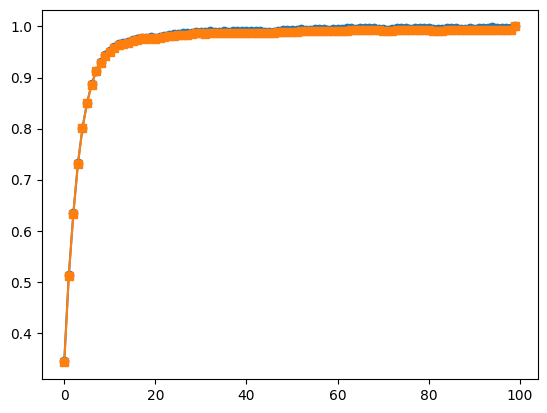

In [73]:
plt.plot(Dscale_store_mat, 'o-', label="MATLAB")
plt.plot(Dscale_store, 's-', label="Python")

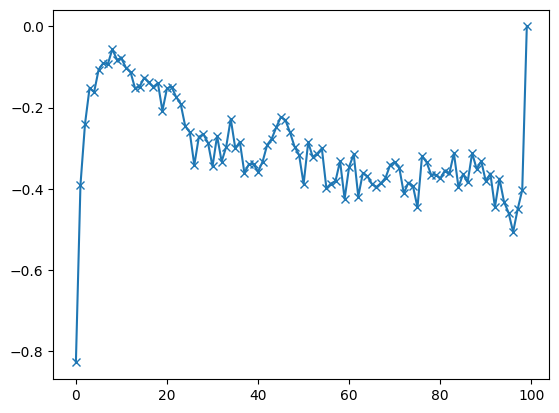

In [74]:
D_diff = (Dscale_store - Dscale_store_mat)*100 / Dscale_store
plt.plot(D_diff, 'x-', label="Difference")

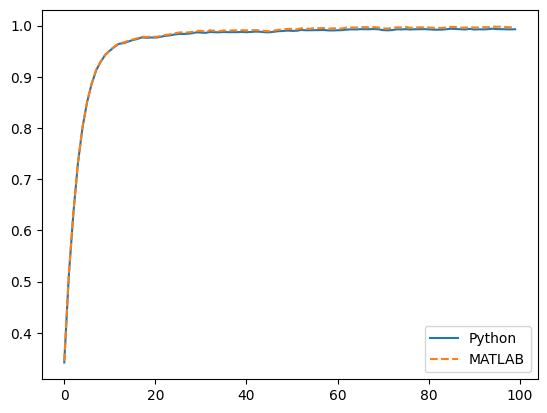

In [75]:
from matplotlib import pyplot as plt

plt.plot(X_overall,label='Python')
plt.plot(X_overall_mat,label='MATLAB',linestyle='dashed')
plt.legend()


In [103]:
print(np.array(True_Distribuiton_all).shape)

(380, 559)


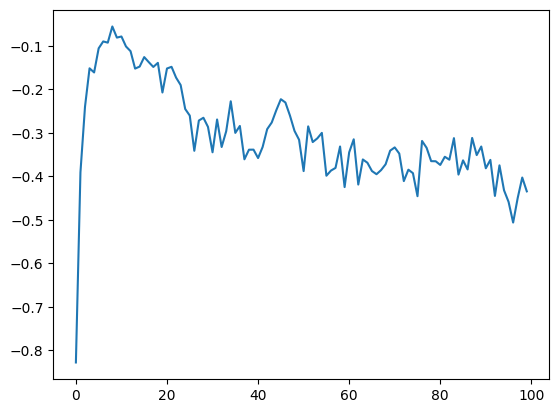

In [76]:
#plotting difference in percentage
X_diff = (X_overall - X_overall_mat)*100 / X_overall
plt.plot(X_diff)

mat_diff = ()

{'name': 'X_overall', 'mean_diff': -0.002928401109107797, 'max_diff': 0.0050266901246556195, 'mean_perc_err': 0.3042146643176411}
{'name': 'M_mat', 'mean_diff': 0.004769523940794952, 'max_diff': 0.18369784150422452, 'mean_perc_err': 49.014656782971066}
{'name': 'M_mat2', 'mean_diff': 0.00432351091248348, 'max_diff': 0.1912238133190886, 'mean_perc_err': 53.09955863699786}


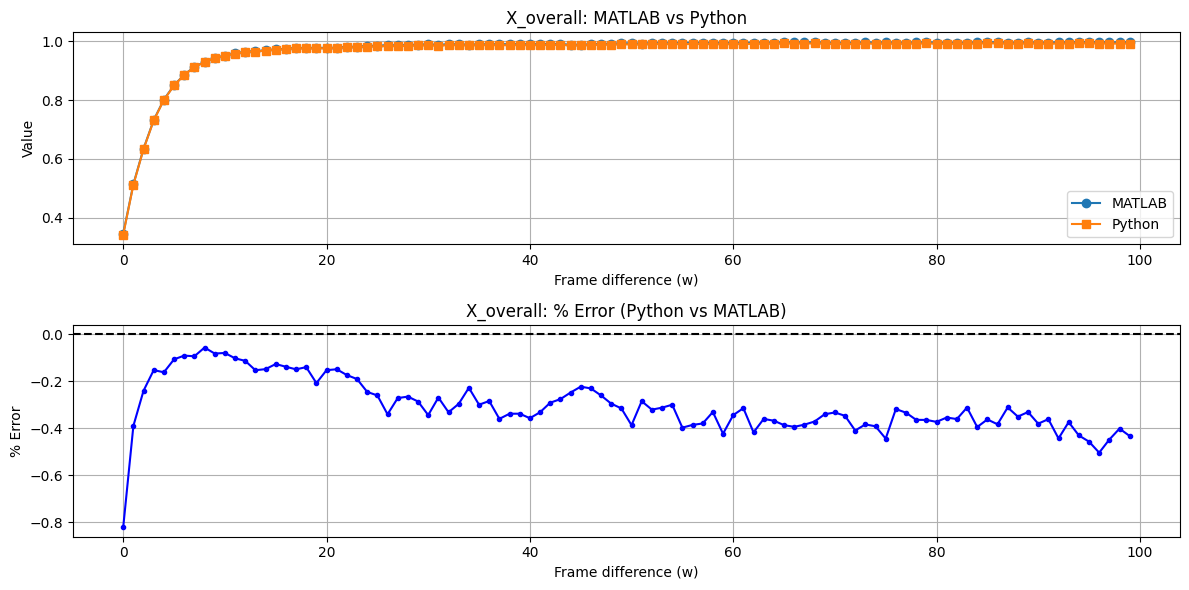

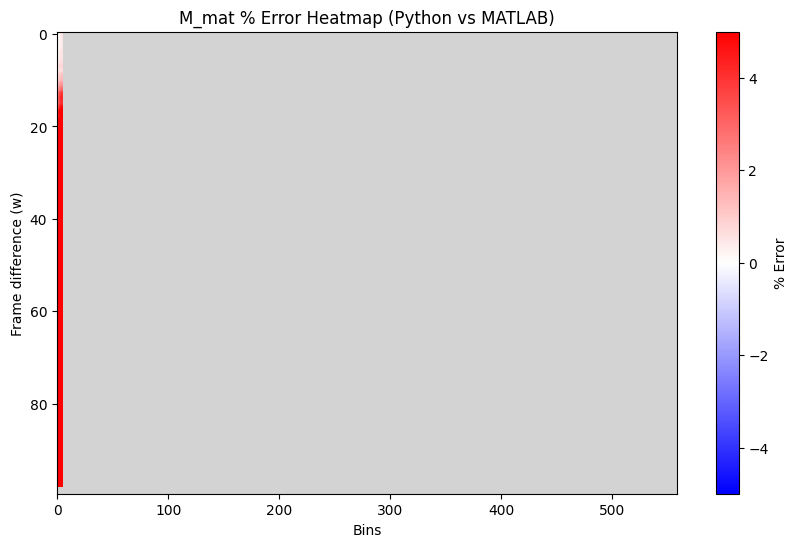

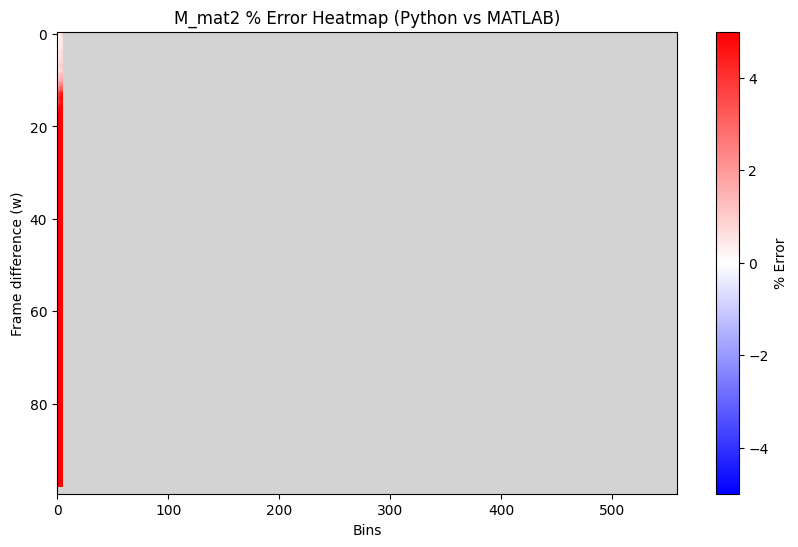

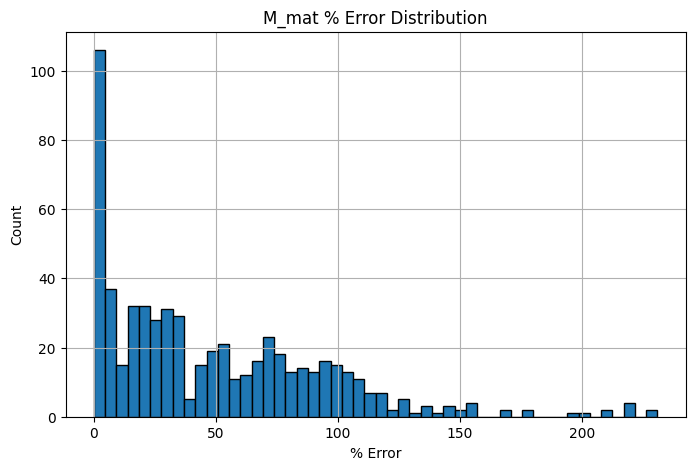

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# === Compare function (safe with NaNs) ===
def compare_arrays(name, mat, py):
    diff = py - mat
    with np.errstate(divide='ignore', invalid='ignore'):
        perc_err = (diff / mat) * 100
        perc_err[~np.isfinite(perc_err)] = np.nan   # mark NaN/Inf where mat=0
    stats = {
        "name": name,
        "mean_diff": float(np.nanmean(diff)),
        "max_diff": float(np.nanmax(np.abs(diff))),
        "mean_perc_err": float(np.nanmean(np.abs(perc_err)))
    }
    return diff, perc_err, stats

# Compare variables
diff_X, perc_X, stats_X = compare_arrays("X_overall", X_overall_mat, X_overall)
diff_M, perc_M, stats_M = compare_arrays("M_mat", M_mat_mat, M_mat)
diff_M2, perc_M2, stats_M2 = compare_arrays("M_mat2", M_mat2_mat, M_mat2)

print(stats_X)
print(stats_M)
print(stats_M2)

# === Plot for X_overall (1D) ===
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(X_overall_mat, 'o-', label="MATLAB")
plt.plot(X_overall, 's-', label="Python")
plt.title("X_overall: MATLAB vs Python")
plt.xlabel("Frame difference (w)"); plt.ylabel("Value")
plt.legend(); plt.grid(True)

plt.subplot(2,1,2)
plt.plot(perc_X, 'b.-')
plt.axhline(0, color='k', linestyle='--')
plt.title("X_overall: % Error (Python vs MATLAB)")
plt.xlabel("Frame difference (w)"); plt.ylabel("% Error")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot for M_mat (heatmap, NaNs in gray) ===
plt.figure(figsize=(10,6))
cmap = plt.cm.bwr
cmap.set_bad(color="lightgray")  # NaNs shown as gray
plt.imshow(perc_M, aspect='auto', cmap=cmap, vmin=-5, vmax=5)
plt.colorbar(label="% Error")
plt.xlabel("Bins"); plt.ylabel("Frame difference (w)")
plt.title("M_mat % Error Heatmap (Python vs MATLAB)")
plt.show()

# === Plot for M_mat2 (heatmap, NaNs in gray) ===
plt.figure(figsize=(10,6))
plt.imshow(perc_M2, aspect='auto', cmap=cmap, vmin=-5, vmax=5)
plt.colorbar(label="% Error")
plt.xlabel("Bins"); plt.ylabel("Frame difference (w)")
plt.title("M_mat2 % Error Heatmap (Python vs MATLAB)")
plt.show()

# Histogram of % errors (M_mat)
plt.figure(figsize=(8,5))
valid_vals = perc_M[~np.isnan(perc_M)]
plt.hist(valid_vals, bins=50, edgecolor='black')
plt.title("M_mat % Error Distribution")
plt.xlabel("% Error"); plt.ylabel("Count")
plt.grid(True)
plt.show()

In [78]:
percM = pd.DataFrame(perc_M)

True_Distribuiton: detected 558 valid bins
Deviation_in_Probabilityt: detected 6 valid bins

True_Distribuiton: Found 0 empty rows (all zeros in MATLAB reference).
Top 5 non-empty rows with highest mean % error in True_Distribuiton:
  Row 35: mean error=0.00%
  Row 132: mean error=0.00%
  Row 54: mean error=0.00%
  Row 362: mean error=0.00%
  Row 182: mean error=0.00%


C:\Users\maula\AppData\Local\Temp\ipykernel_11340\2434292760.py:17: RuntimeWarning: invalid value encountered in divide
  perc_err = (diff / mat) * 100


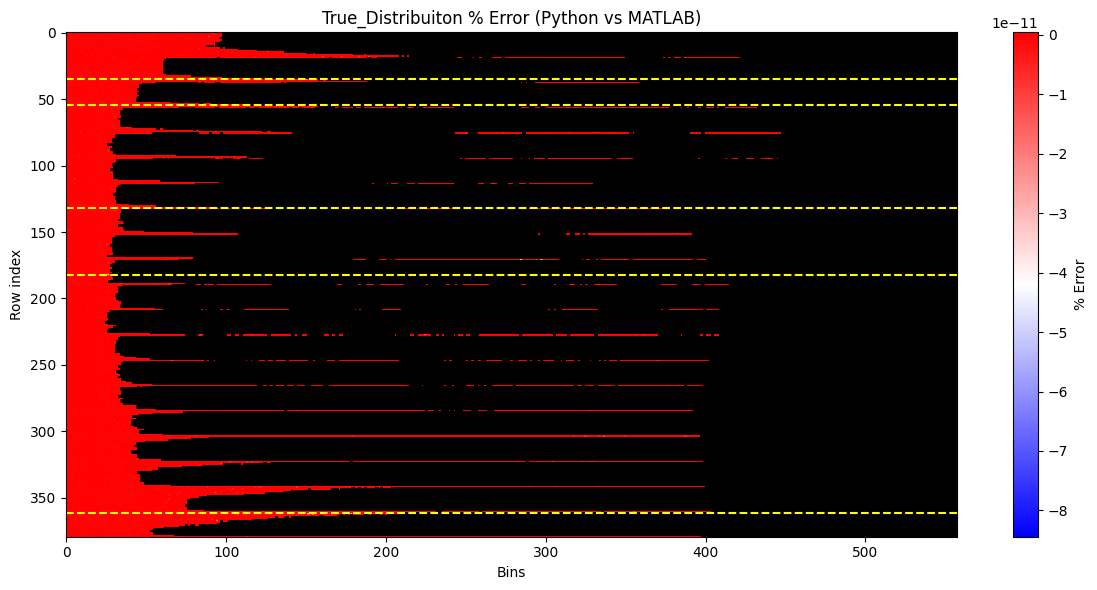

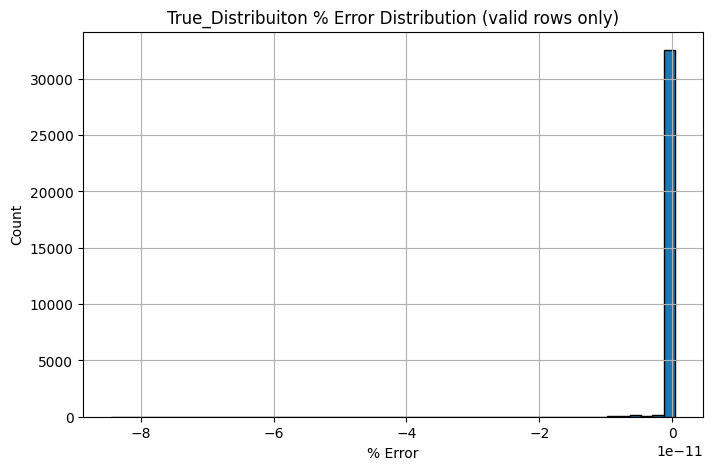


Deviation_in_Probabilityt: Found 380 empty rows (all zeros in MATLAB reference).
Top 5 non-empty rows with highest mean % error in Deviation_in_Probabilityt:
  Row 4296: Image=43, w=97, mean error=239.52%
  Row 5096: Image=51, w=97, mean error=239.54%
  Row 31796: Image=318, w=97, mean error=239.59%
  Row 29396: Image=294, w=97, mean error=239.64%
  Row 31696: Image=317, w=97, mean error=239.72%


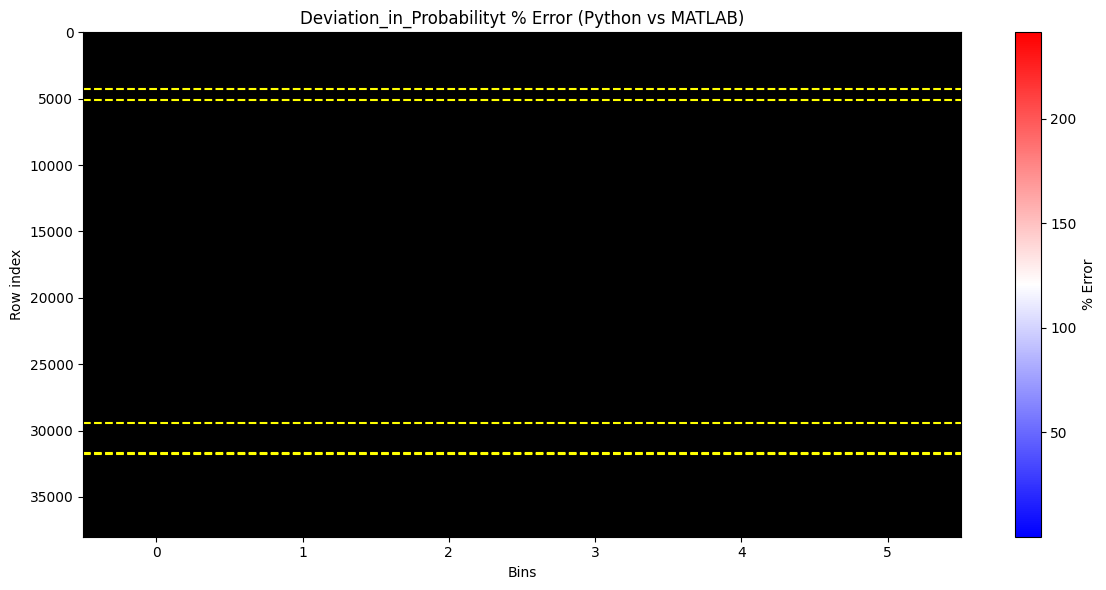

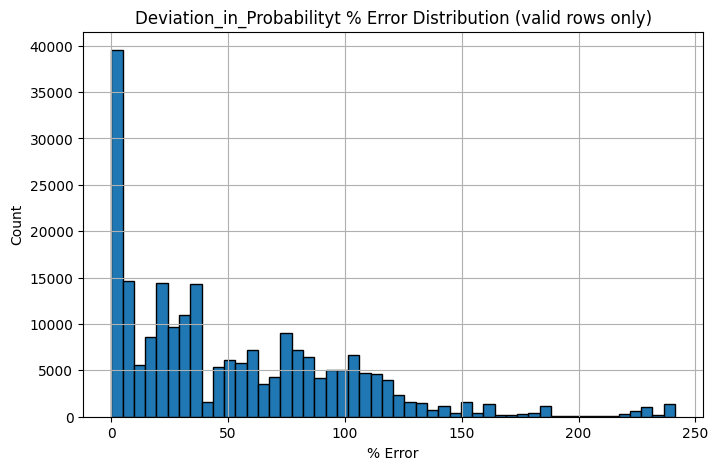

In [ ]:

# === Load MATLAB & Python data + indices ===
Dev_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\Deviation_in_Probabilityt_mat.csv", header=None).values
Dev_py = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC_python\Deviation_in_Probabilityt_py.csv", header=None).values
Dev_idx_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\Deviation_in_Probabilityt_index_mat.csv", header=None).values
Dev_idx_py = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC_python\Deviation_in_Probabilityt_index_py.csv", header=None).values
True_mat = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC-main\Main_DDC_Folder\True_Distribuiton_mat.csv", header=None).values
True_py = pd.read_csv(r"C:\Users\maula\Desktop\PhD FIles\Codes\DDC_python\True_Distribuiton_py.csv", header=None).values

# === Function to trim trailing empty bins ===
def trim_valid_bins(mat, py, tol=1e-12):
    # Find last column in MATLAB with any nonzero values
    nonzero_cols = np.where(np.any(np.abs(mat) > tol, axis=0))[0]
    if len(nonzero_cols) == 0:
        return mat[:, :0], py[:, :0], 0
    max_col = nonzero_cols[-1] + 1
    return mat[:, :max_col], py[:, :max_col], max_col

# === Generic compare function ===
def compare_and_plot(name, mat, py, row_index=None, perc_range=(-10,10)):
    diff = py - mat
    perc_err = (diff / mat) * 100

    # with np.errstate(divide="ignore", invalid="ignore"):
    #     perc_err = (diff / mat) * 100
    #     perc_err[~np.isfinite(perc_err)] = np.nan

    # Detect empty rows
    empty_rows = [r for r in range(mat.shape[0]) if np.allclose(mat[r,:], 0)]
    print(f"\n{name}: Found {len(empty_rows)} empty rows (all zeros in MATLAB reference).")

    # Compute mean row-wise error
    row_mean_err = []
    for r in range(mat.shape[0]):
        if r in empty_rows:
            row_mean_err.append(np.nan)
        else:
            row_mean_err.append(np.nanmean(np.abs(perc_err[r,:])))
    row_mean_err = np.array(row_mean_err)

    # Identify worst rows
    valid_idx = np.where(~np.isnan(row_mean_err))[0]
    if len(valid_idx) > 0:
        top_rows = valid_idx[np.argsort(row_mean_err[valid_idx])[-5:]]
        print(f"Top 5 non-empty rows with highest mean % error in {name}:")
        for r in top_rows:
            if row_index is not None:
                img, w = row_index[r]
                print(f"  Row {r}: Image={int(img)}, w={int(w)}, mean error={row_mean_err[r]:.2f}%")
            else:
                print(f"  Row {r}: mean error={row_mean_err[r]:.2f}%")
    else:
        top_rows = []

    # Heatmap
    cmap = plt.cm.bwr
    cmap.set_bad(color="black")
    plt.figure(figsize=(12,6))
    plt.imshow(perc_err, aspect="auto", cmap=cmap)
    plt.colorbar(label="% Error")
    plt.xlabel("Bins")
    plt.ylabel("Row index")
    plt.title(f"{name} % Error (Python vs MATLAB)")

    for r in top_rows:
        plt.axhline(r, color="yellow", linestyle="--", linewidth=1.5)

    plt.tight_layout()
    plt.show()

    # Histogram
    plt.figure(figsize=(8,5))
    valid_vals = perc_err[~np.isnan(perc_err)]
    plt.hist(valid_vals, bins=50, edgecolor="black")
    plt.title(f"{name} % Error Distribution (valid rows only)")
    plt.xlabel("% Error"); plt.ylabel("Count")
    plt.grid(True)
    plt.show()

    return pd.DataFrame(perc_err), pd.DataFrame(diff)

# === Trim to valid bins only ===
True_mat_trim, True_py_trim, n_true_bins = trim_valid_bins(True_mat, True_py)
Dev_mat_trim, Dev_py_trim, n_dev_bins = trim_valid_bins(Dev_mat, Dev_py)

print(f"True_Distribuiton: detected {n_true_bins} valid bins")
print(f"Deviation_in_Probabilityt: detected {n_dev_bins} valid bins")

# === Run comparisons on trimmed arrays ===
compare_and_plot("True_Distribuiton", True_mat_trim, True_py_trim, row_index=None, perc_range=(-5,5))
perc_err_dev, perc_diff_dev = compare_and_plot("Deviation_in_Probabilityt", Dev_mat_trim, Dev_py_trim, row_index=Dev_idx_mat, perc_range=(-10,10))


In [113]:
print(perc_err_dev)

                0           1           2           3           4           5
0        0.006055    0.013106    0.039354    0.090088    0.231151    0.637655
1        0.007736    0.016650    0.048971    0.107832    0.250174    0.540832
2        0.010359    0.022138    0.063482    0.133692    0.280596    0.507743
3        0.013930    0.029469    0.081618    0.162464    0.305895    0.477542
4        0.029227    0.061040    0.162114    0.303375    0.516363    0.723028
...           ...         ...         ...         ...         ...         ...
37995   84.625561  137.519256  170.589662  180.982233  183.498330  184.953593
37996  109.280609  178.274509  221.684212  235.369662  238.686136  240.604883
37997   67.915673  112.022645  140.278855  149.269485  151.454249  152.719319
37998   49.067750   81.517547  102.552806  109.286846  110.926256  111.876082
37999         NaN         NaN         NaN         NaN         NaN         NaN

[38000 rows x 6 columns]
